In [1]:
# Setup
!pip install -q "librosa"
!wget "https://github.com/polito-EAD-2026/media/raw/refs/heads/dev/potter.wav"

--2025-10-09 21:31:54--  https://github.com/polito-EAD-2026/media/raw/refs/heads/dev/potter.wav
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/polito-EAD-2026/media/refs/heads/dev/potter.wav [following]
--2025-10-09 21:31:54--  https://raw.githubusercontent.com/polito-EAD-2026/media/refs/heads/dev/potter.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 777238 (759K) [audio/wav]
Saving to: ‘potter.wav’

potter.wav          100%[===================>] 759.02K  --.-KB/s    in 0.06s   

2025-10-09 21:31:54 (13.1 MB/s) - ‘potter.wav’ saved [777238/777238]



In [2]:
import librosa
import librosa.display
import soundfile as sf

import numpy as np
import scipy

from matplotlib import pyplot as plt
%matplotlib inline

import IPython
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from pprint import pprint

In [3]:
def quantize_uniform_tread(x, N=8):
  qmin, qmax, qlevel = -1, +1, 2**N-1 # defaults
  qstep = (qmax-qmin) / qlevel
  xnorm = (x-qmin) * qlevel / (qmax-qmin)
  xnorm[xnorm > qlevel] = qlevel
  xnorm[xnorm < 0] = 0
  xnorm_quant = np.floor(xnorm)
  xquant = xnorm_quant * (qmax-qmin) / qlevel
  xquant = xquant + qmin + qstep/2
  return xquant

def plot_vs_time(w, t, xlim=None, ylim=[-1, +1], fig=None):
  fig, ax = plt.subplots(figsize=(12,3)) if fig is None else fig
  ax.plot(t,w,'-')
  ax.set_xlabel('Time (s)')
  ax.set_ylabel('Amplitude')
  ax.set_xlim(xlim) if xlim is not None else plt.xlim(t[0],t[-1])
  ax.set_ylim(ylim) if ylim is not None else None
  fig.tight_layout()
  # ax.grid()
  # plt.show()

def SNR(original, quantized):
  noise = quantized - original
  powS = np.sum(original**2)
  powN = np.sum(noise**2)
  return 10*np.log10(powS/powN)

def normalize(x):
  return x / np.max(np.abs(x))

def RMS(x):
  return np.sqrt(np.mean(x**2))

Riportare nel foglio di calcolo i seguenti valori
RMS (colonna A): 0.06869259476661682
SNR (colonna B): 30.32427978515625

Ascoltare l'audio quantizzato.
Quanto è "buono" un SNR di: 30 dB?


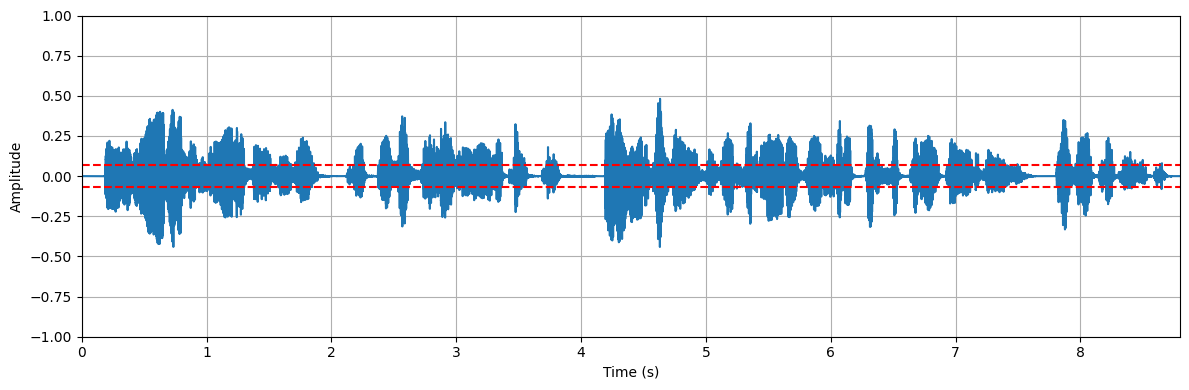

In [4]:
###### ESERCIZIO: QUANTIZATION SNR vs RMS
#
# Compilare il GSheet a questo link: https://docs.google.com/spreadsheets/d/1Mvx-SDGy89HaODUmuyzAGZ8RjGiq1igECk1gVaEOIb8/edit?usp=sharing
# Inserire il valore di RMS nella colonna A
# Inserire il valore di SNR (con N=8 bit) nella colonna B
#
# n.b. selezionata la cella, inserire il valore nella barra delle formule così da incollare solo il valore
#

A = 1.5 # TODO: Variare il seguente valore di ampiezza per ottenere diverse coppie di valori

# Caricamento file audio
in_filename = "potter.wav"
x, sr = librosa.load(in_filename, sr=None)
t = np.arange(x.shape[0]) / sr

# Numero di bit da utilizzare
N = 8

# Variazione intensità del segnale
xA = A * x
xAq = quantize_uniform_tread(xA, N)

# Calcolo RMS ed SNR
rms = RMS(xA)
snr = SNR(xA, xAq)

# visualizzazione
fig, ax = plt.subplots(figsize=(12,4))
plot_vs_time(xA,t, fig=(fig,ax))
ax.grid()
ax.axhline(y=rms, color='r', linestyle='--', label='RMS')
ax.axhline(y=-rms, color='r', linestyle='--', label='RMS')

print(f"Riportare nel foglio di calcolo i seguenti valori")
print(f"RMS (colonna A): {rms}")
print(f"SNR (colonna B): {snr}")

print()
print(f'Ascoltare l\'audio quantizzato.\nQuanto è "buono" un SNR di: {snr:.0f} dB?')
IPython.display.display(IPython.display.Audio(xAq,rate=sr) )